# SkillPulse — Phase 4: XGBoost Model Training & Optimisation

This notebook trains an XGBoost regressor to predict salary distributions based on extracted technical skills and country indicators. It implements hyperparameter tuning using Optuna, performs 5-fold cross-validation, generates feature importance plots, saves the model to disk, and logs the training runs in MySQL.

## 1. Imports and Environment Setup

In [1]:
import os, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from urllib.parse import quote_plus
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.facecolor':'#0f172a','axes.facecolor':'#1e293b','figure.dpi':120})
load_dotenv(dotenv_path='../.env')

c:\Users\Kartik Kumar Singh\Desktop\skillpulse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 2. Load Exported Datasets

In [2]:
EXPORTS_DIR = '../data_exports'
MODELS_DIR  = '../models'
PLOTS_DIR   = '../eda_plots'
os.makedirs(MODELS_DIR, exist_ok=True)

X = pd.read_csv(f'{EXPORTS_DIR}/X_train.csv')
y = pd.read_csv(f'{EXPORTS_DIR}/y_train.csv')['log_salary_usd']
with open(f'{EXPORTS_DIR}/feature_names.json', 'r') as f:
    feature_names = json.load(f)

print(f'Feature matrix X: {X.shape}  | Target y: {y.shape}')

Feature matrix X: (31534, 48)  | Target y: (31534,)


## 3. Train/Test Split (80/20)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}')

Train samples: 25227  |  Test samples: 6307


## 4. Baseline Model Training

In [4]:
print('Training baseline model...')
baseline_model = xgb.XGBRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
print('Baseline metrics on Test set:')
print(f'MAE:  {mean_absolute_error(y_test, baseline_preds):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, baseline_preds)):.4f}')
print(f'R2:   {r2_score(y_test, baseline_preds):.4f}')

Training baseline model...
Baseline metrics on Test set:
MAE:  0.3009
RMSE: 0.6027
R2:   0.1862


## 5. Optuna Hyperparameter Optimization

In [5]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        rmse_scores.append(np.sqrt(mean_squared_error(y_va, preds)))
    return np.mean(rmse_scores)

print('Optimizing parameters (30 trials)...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
best_params = study.best_params
print(f'Best params: {best_params}')
print(f'Best CV RMSE: {study.best_value:.4f}')

Optimizing parameters (30 trials)...
Best params: {'n_estimators': 291, 'max_depth': 10, 'learning_rate': 0.023139644174056874, 'subsample': 0.5075395432430565, 'colsample_bytree': 0.6089071991978964, 'min_child_weight': 7, 'reg_alpha': 8.636172812814957, 'reg_lambda': 9.93296881992883}
Best CV RMSE: 0.5656


## 6. Train Final Model and Evaluate

In [6]:
print('Training final model...')
best_model = xgb.XGBRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

test_preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2 = r2_score(y_test, test_preds)

print('\nFinal Test Metrics:')
print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2:   {r2:.4f}')

# Raw dollar conversion error
y_test_raw = np.expm1(y_test)
test_preds_raw = np.expm1(test_preds)
raw_mae = mean_absolute_error(y_test_raw, test_preds_raw)
print(f'Average absolute prediction error: ${raw_mae:,.2f} USD')

Training final model...

Final Test Metrics:
MAE:  0.3001
RMSE: 0.5998
R2:   0.1940
Average absolute prediction error: $30,441.34 USD


## 7. Feature Importance

C:\Users\Kartik Kumar Singh\AppData\Local\Temp\ipykernel_21968\2244667045.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.head(15), x='Importance', y='Feature', palette='viridis')


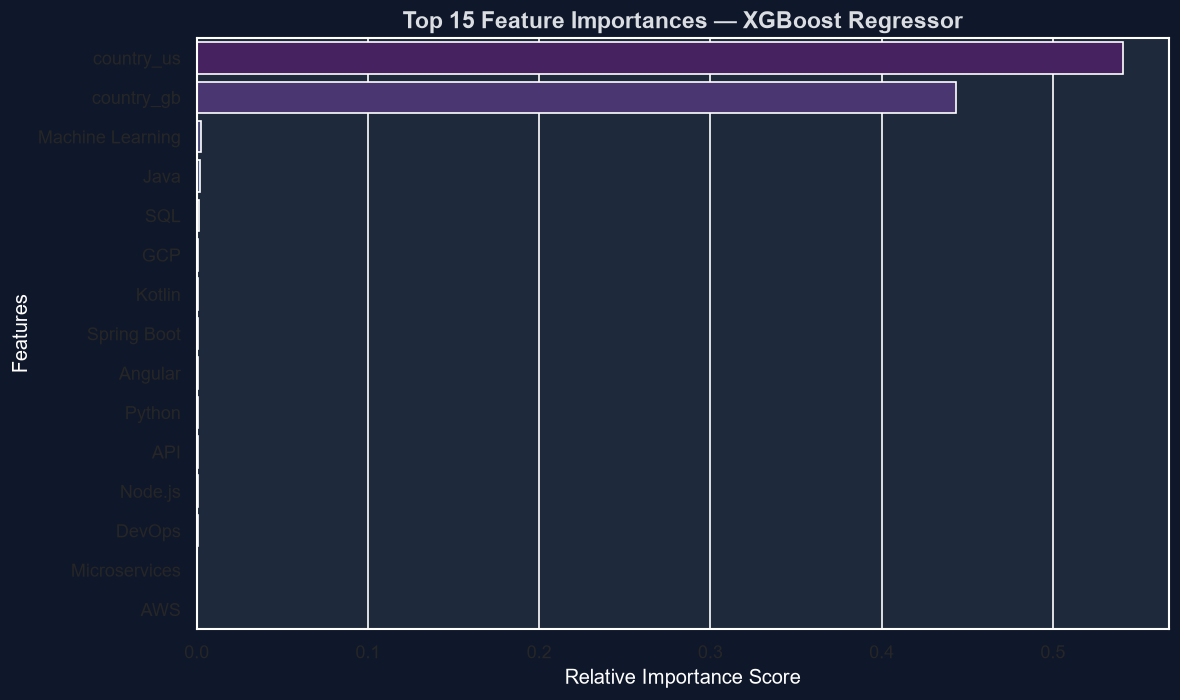

In [7]:
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — XGBoost Regressor', fontsize=14, color="#dadde1", fontweight='bold')
plt.xlabel('Relative Importance Score',color="white")
plt.ylabel('Features',color="white")
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Save Model & Log to Database

In [8]:
model_path = f'{MODELS_DIR}/xgboost_model.joblib'
joblib.dump(best_model, model_path)
print(f'Model saved to: {model_path}')

# Connect and log to MySQL
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')
engine = create_engine(f"mysql+pymysql://{DB_USER}:{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

notes_dict = {
    'best_params': best_params,
    'r2': round(float(r2), 4),
    'raw_mae_usd': round(float(raw_mae), 2)
}

with engine.begin() as conn:
    sql = text("INSERT INTO model_runs (model_type, mae, rmse, notes) VALUES (:model_type, :mae, :rmse, :notes)")
    conn.execute(sql, {
        'model_type': 'xgboost',
        'mae': float(mae),
        'rmse': float(rmse),
        'notes': json.dumps(notes_dict)
    })
print('Run logged to model_runs table successfully!')

Model saved to: ../models/xgboost_model.joblib
Run logged to model_runs table successfully!
